# Quantitative Risk & Portfolio Dashboard

Objective: Analyze the risk/return profile of a tech portfolio (AAPL, MSFT, GOOGL) and optimize asset allocation using Monte Carlo simulations.

Key Metrics:

Sharpe Ratio Optimization: Identifying the efficient frontier.

Value at Risk (VaR): quantifying tail risk at 95% confidence.

Maximum Drawdown: Stress-testing portfolio resilience.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import sklearn

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
def calculate_drawdown(series):
    cumulative = (1 + series).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    return drawdown, drawdown.min()

def calculate_var(series, confidence_level=0.05):
    return np.percentile(series, confidence_level * 100)

def simulate_portfolios(daily_returns, num_portfolios=1000):

    np.random.seed(42)
    results = np.zeros((3, num_portfolios))
    weights_record = []
    cov_matrix = daily_returns.cov() * 252

    for i in range(num_portfolios):
        weights = np.random.random(len(daily_returns.columns))
        weights /= np.sum(weights)
        weights_record.append(weights)
        portfolio_return = np.sum(weights * daily_returns.mean()) * 252
        portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        results[0,i] = portfolio_return
        results[1,i] = portfolio_std_dev
        results[2,i] = results[0,i] / results[1,i]

    max_sharpe_idx = np.argmax(results[2])
    best_weights = weights_record[max_sharpe_idx]
    return results, best_weights, max_sharpe_idx

In [ ]:
tickers = ['AAPL', 'MSFT', 'GOOGL']
print(f"Downloading data for: {tickers}...")
df = yf.download(tickers, start='2023-01-01', auto_adjust=False)['Adj Close']

daily_returns = df.pct_change().dropna()
print("returns")
print(df.tail())

[*********************100%***********************]  3 of 3 completed

returns
Ticker            AAPL       GOOGL        MSFT
Date                                          
2026-02-09  274.619995  324.320007  413.600006
2026-02-10  273.679993  318.579987  413.269989
2026-02-11  275.500000  310.959991  404.369995
2026-02-12  261.730011  309.000000  401.839996
2026-02-13  255.779999  305.720001  401.320007


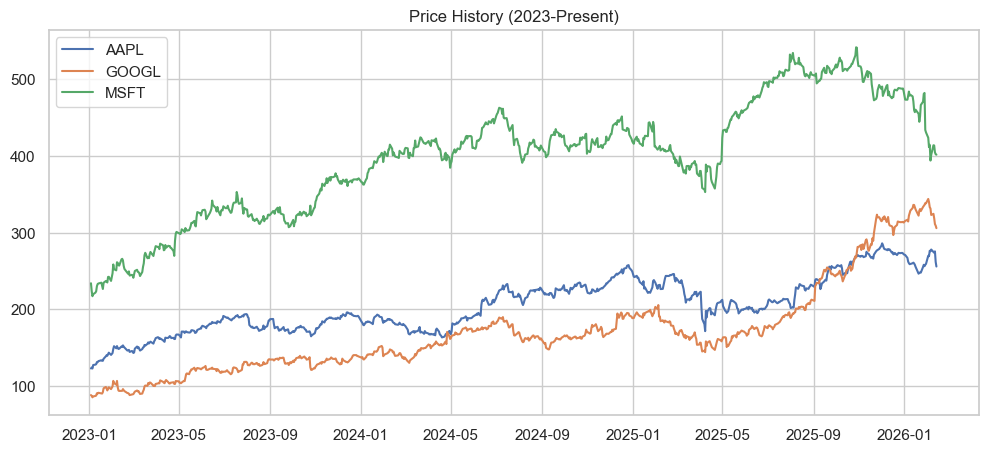

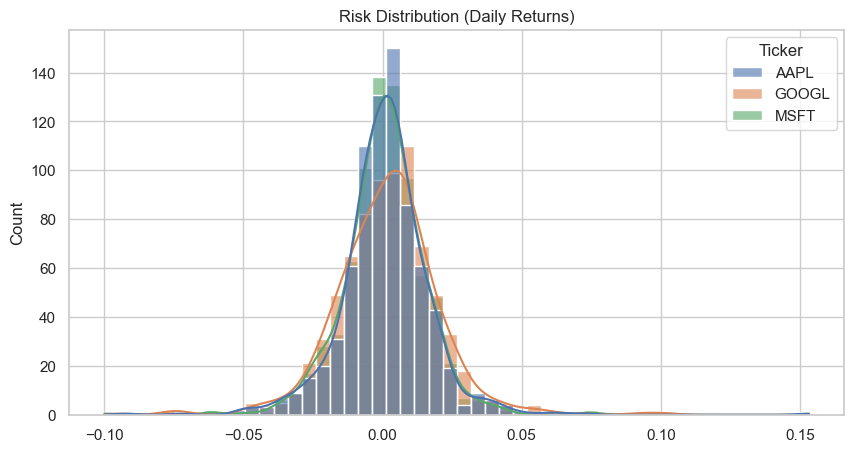

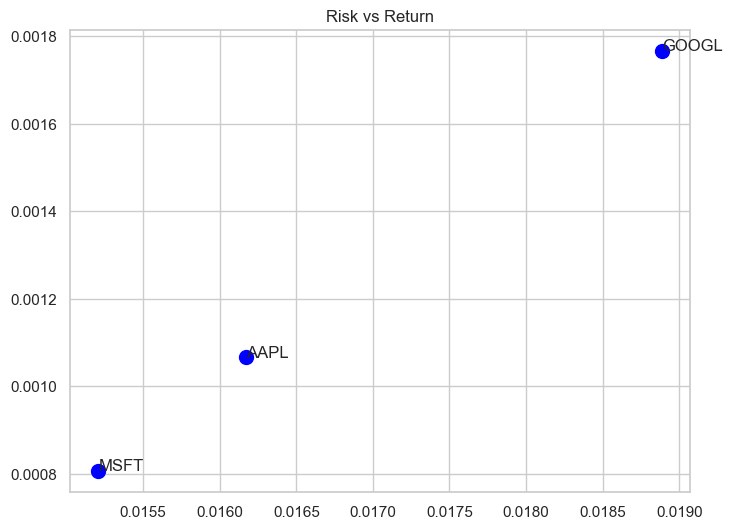

In [ ]:
plt.figure(figsize=(12, 5))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)
plt.title("Price History (2023-Present)")
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
sns.histplot(daily_returns, bins=50, kde=True, alpha=0.6)
plt.title("Risk Distribution (Daily Returns)")
plt.show()


avg_daily_ret = daily_returns.mean()
risk = daily_returns.std()
plt.figure(figsize=(8, 6))
plt.scatter(risk, avg_daily_ret, s=100, color='blue')
for ticker in tickers:
    plt.text(risk[ticker], avg_daily_ret[ticker], ticker, fontsize=12)
plt.title('Risk vs Return')
plt.grid(True)
plt.show()

Raw prices can be noisy. To identify the true trend, I'll overlay a 30-day Simple Moving Average (SMA) to dampen daily volatility.

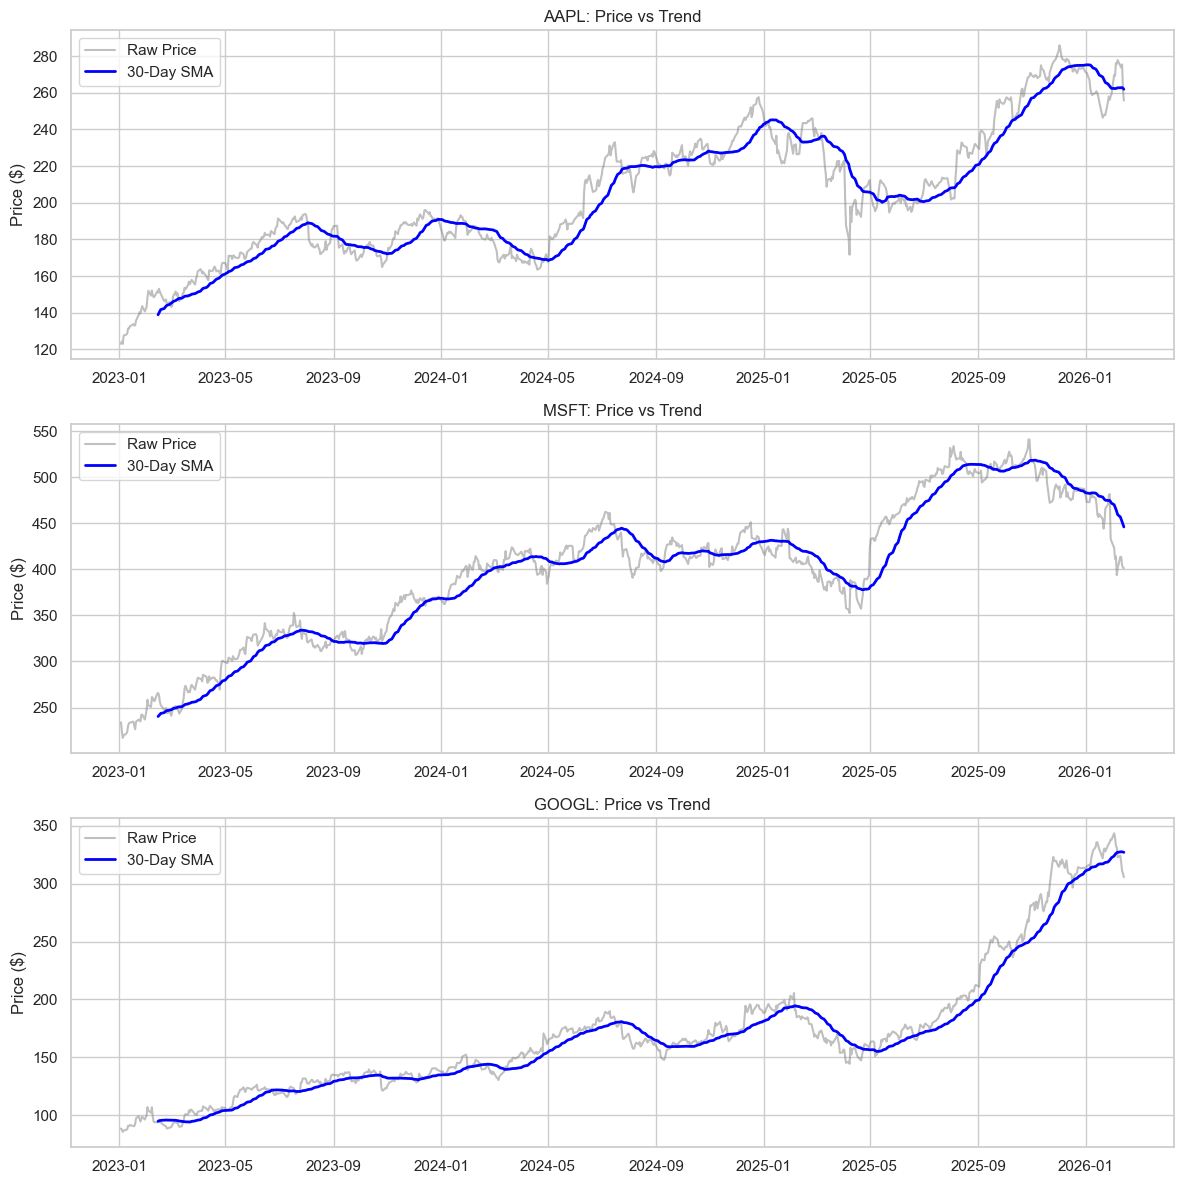

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i, ticker in enumerate(tickers):

    sma = df[ticker].rolling(window=30).mean()


    axes[i].plot(df.index, df[ticker], label='Raw Price', color='gray', alpha=0.5)
    axes[i].plot(df.index, sma, label='30-Day SMA', color='blue', linewidth=2)


    axes[i].set_title(f'{ticker}: Price vs Trend')
    axes[i].set_ylabel('Price ($)')
    axes[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

Looking at the historical returns, it's unclear what the optimal mix is. A simple 50/30/20 split is a guess. To find the mathematically optimal portfolio, I will simulate 1,000 random weight combinations to map the Efficient Frontier.

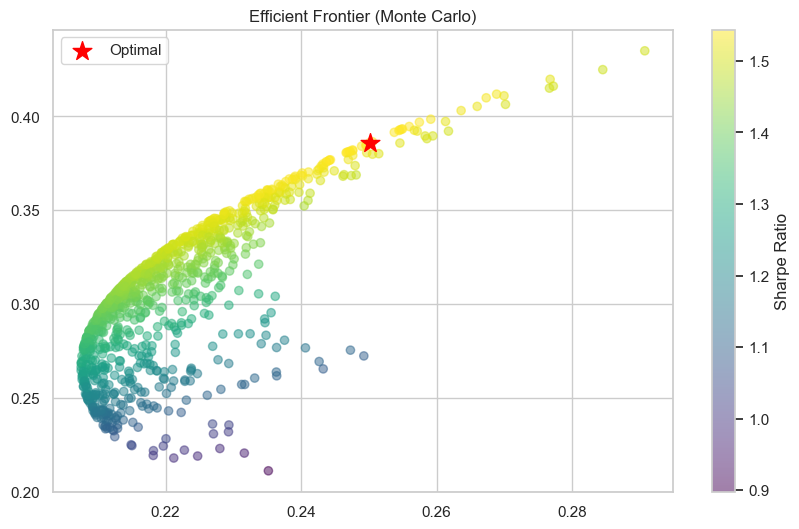

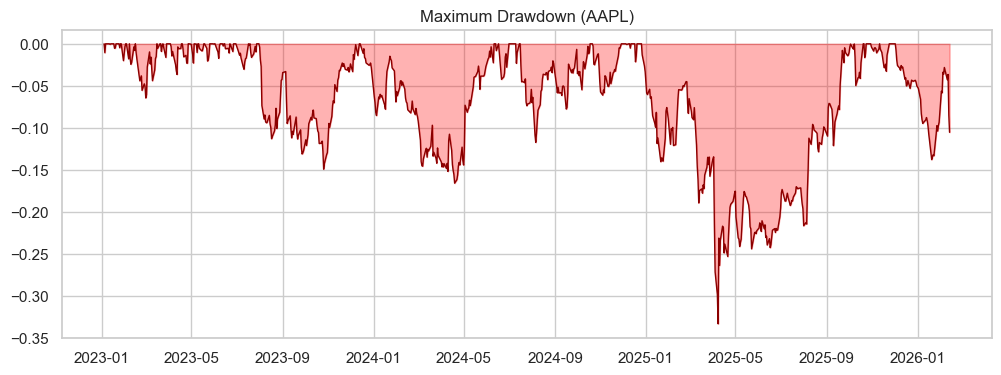

In [ ]:
results, best_weights, max_idx = simulate_portfolios(daily_returns)

plt.figure(figsize=(10, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(results[1,max_idx], results[0,max_idx], c='red', s=200, marker='*', label='Optimal')
plt.title('Efficient Frontier (Monte Carlo)')
plt.legend()
plt.show()


drawdown, min_dd = calculate_drawdown(daily_returns['AAPL'])

plt.figure(figsize=(12, 4))
plt.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
plt.plot(drawdown.index, drawdown, color='darkred', lw=1)
plt.title("Maximum Drawdown (AAPL)")
plt.show()

In [ ]:
aapl_var = calculate_var(daily_returns['AAPL'])

print("\n" + "="*40)
print("PORTFOLIO OPTIMIZATION REPORT")
print("="*40)
print(f"Optimal Allocation: {dict(zip(tickers, np.round(best_weights, 2)))}")
print(f"Best Sharpe Ratio: {results[2, max_idx]:.2f}")
print("-" * 40)
print(f"AAPL Stress Test:")
print(f"  - Max Drawdown: {min_dd:.2%}")
print(f"  - VaR (95%): {aapl_var:.2%}")
print("="*40)


PORTFOLIO OPTIMIZATION REPORT
Optimal Allocation: {'AAPL': np.float64(0.27), 'MSFT': np.float64(0.68), 'GOOGL': np.float64(0.04)}
Best Sharpe Ratio: 1.54
----------------------------------------
AAPL Stress Test:
  - Max Drawdown: -33.36%
  - VaR (95%): -2.41%


--- Simulating 1,000 Portfolios ---
Best Portfolio: [0.27483867 0.68104439 0.04411694]
Best Return: 0.3860927368365555
Best Risk: 0.2501328490746195


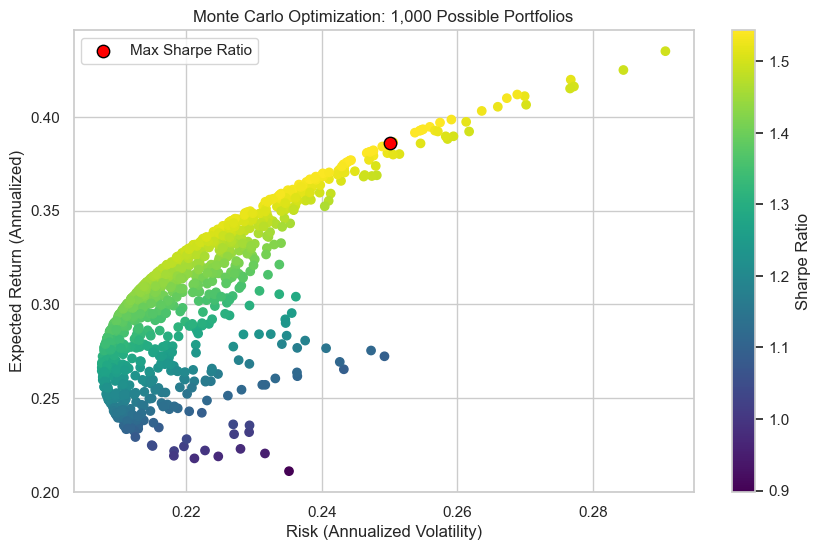

In [ ]:
print("--- Simulating 1,000 Portfolios ---")
np.random.seed(42)


p_ret = []
p_vol = []
p_weights = []

num_assets = len(df.columns)
num_portfolios = 1000


cov_matrix = daily_returns.cov() * 252

for i in range(num_portfolios):

    weights = np.random.random(num_assets)
    weights /= np.sum(weights) # Normalize to sum to 1.0
    p_weights.append(weights)


    returns = np.sum(weights * daily_returns.mean()) * 252
    p_ret.append(returns)


    var = np.dot(weights.T, np.dot(cov_matrix, weights))
    sd = np.sqrt(var)
    p_vol.append(sd)


p_ret = np.array(p_ret)
p_vol = np.array(p_vol)
p_weights = np.array(p_weights)


sharpe_arr = p_ret / p_vol
max_sr_index = sharpe_arr.argmax()

print("Best Portfolio:", p_weights[max_sr_index])
print("Best Return:", p_ret[max_sr_index])
print("Best Risk:", p_vol[max_sr_index])


plt.figure(figsize=(10, 6))

plt.scatter(p_vol, p_ret, c=sharpe_arr, cmap='viridis')
plt.colorbar(label='Sharpe Ratio')

plt.scatter(p_vol[max_sr_index], p_ret[max_sr_index], c='red', s=80, edgecolors='black', label='Max Sharpe Ratio')

plt.title('Monte Carlo Optimization: 1,000 Possible Portfolios')
plt.xlabel('Risk (Annualized Volatility)')
plt.ylabel('Expected Return (Annualized)')
plt.legend()
plt.show()

#PART 2 : Buy-Sell Signaling Using Logistic Regression in Scikit-Learn


In [ ]:
# === FEATURE ENGINEERING FOR CLASSIFICATION ===
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

target_stk = 'AAPL'
df_ml = df[[target_stk]].copy()

df_ml['Return'] = df_ml[target_stk].pct_change()

# TARGET: Will the stock go UP tomorrow? (1 = Yes, 0 = No)
df_ml['Target'] = (df_ml['Return'].shift(-1) > 0).astype(int)

# FEATURES: Market conditions that might predict tomorrow's direction
# 1. Recent momentum: 5-day return
df_ml['Return_5d'] = df_ml[target_stk].pct_change(5)

# 2. Volatility: How choppy has the stock been?
df_ml['Volatility_20d'] = df_ml['Return'].rolling(window=20).std()

# 3. Trend strength: Is price above its moving average?
df_ml['Price_vs_SMA20'] = (df_ml[target_stk] / df_ml[target_stk].rolling(20).mean()) - 1

# 4. Recent momentum: 1-day return (yesterday's performance)
df_ml['Return_1d'] = df_ml['Return']

df_ml.dropna(inplace=True)

X = df_ml[['Return_1d', 'Return_5d', 'Volatility_20d', 'Price_vs_SMA20']].values
y = df_ml['Target'].values

split_point = int(len(X) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")
print(f"Train period: {df_ml.index[0]} to {df_ml.index[split_point-1]}")
print(f"Test period: {df_ml.index[split_point]} to {df_ml.index[-1]}")

print(f"\n=== Class Distribution ===")
print(f"Training set:")
print(f"  DOWN days (0): {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train):.1%})")
print(f"  UP days (1): {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train):.1%})")
print(f"\nTest set:")
print(f"  DOWN days (0): {np.sum(y_test == 0)} ({np.sum(y_test == 0)/len(y_test):.1%})")
print(f"  UP days (1): {np.sum(y_test == 1)} ({np.sum(y_test == 1)/len(y_test):.1%})")

Training samples: 609 | Test samples: 153
Train period: 2023-02-01 00:00:00 to 2025-07-08 00:00:00
Test period: 2025-07-09 00:00:00 to 2026-02-13 00:00:00

=== Class Distribution ===
Training set:
  DOWN days (0): 276 (45.3%)
  UP days (1): 333 (54.7%)

Test set:
  DOWN days (0): 75 (49.0%)
  UP days (1): 78 (51.0%)



=== Model Performance ===
Accuracy: 52.29%

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.51      0.60      0.55        75
          UP       0.54      0.45      0.49        78

    accuracy                           0.52       153
   macro avg       0.52      0.52      0.52       153
weighted avg       0.53      0.52      0.52       153



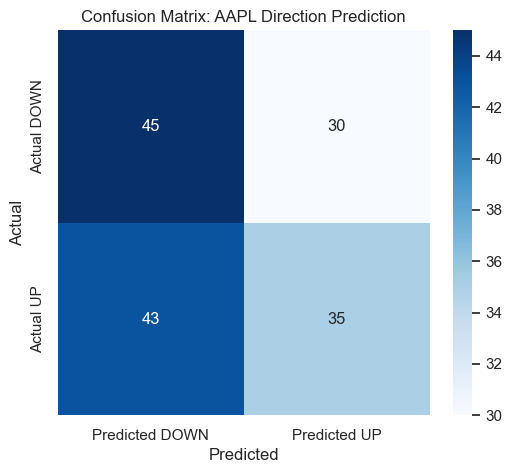

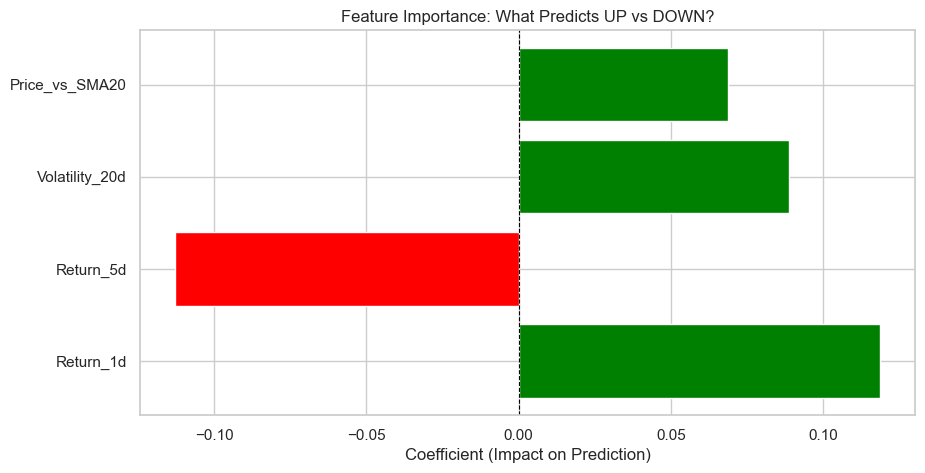

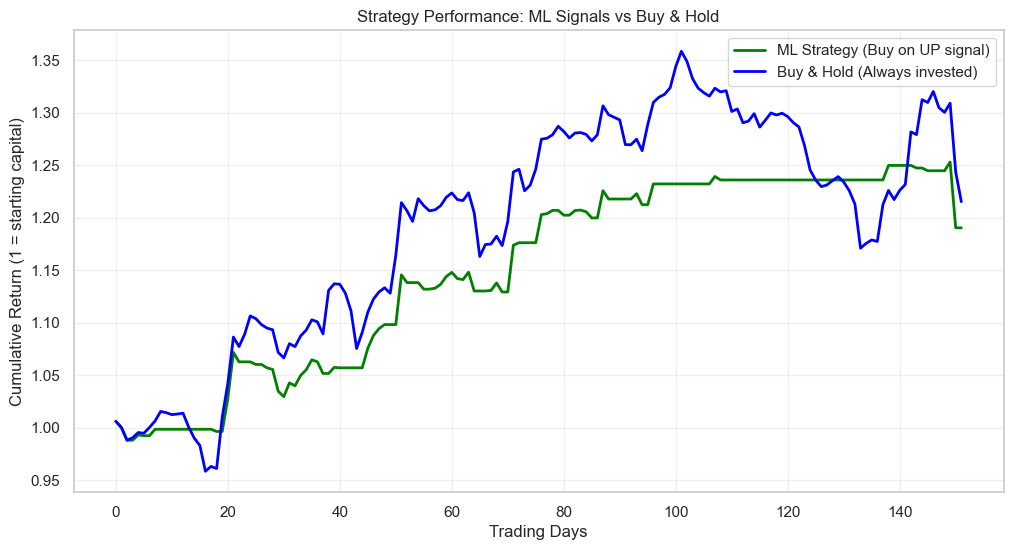


=== Backtest Results ===
ML Strategy Total Return: 19.02%
Buy & Hold Total Return: 21.51%
ML Strategy Sharpe Ratio: 2.08
Buy & Hold Sharpe Ratio: 1.54

Win Rate (when predicting UP): 54.69%


In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the classifier with balanced class weights
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probability of UP

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n=== Model Performance ===")
print(f"Accuracy: {accuracy:.2%}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['DOWN', 'UP']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted DOWN', 'Predicted UP'],
            yticklabels=['Actual DOWN', 'Actual UP'])
plt.title('Confusion Matrix: AAPL Direction Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

feature_names = ['Return_1d', 'Return_5d', 'Volatility_20d', 'Price_vs_SMA20']
coefficients = model.coef_[0]

plt.figure(figsize=(10, 5))
plt.barh(feature_names, coefficients, color=['green' if c > 0 else 'red' for c in coefficients])
plt.xlabel('Coefficient (Impact on Prediction)')
plt.title('Feature Importance: What Predicts UP vs DOWN?')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.show()

# Strategy: Buy when model predicts UP (1), stay in cash when predicts DOWN (0)
test_returns = df_ml['Return'].iloc[split_point+1:].values  # Actual next-day returns

strategy_returns = y_pred[:-1] * test_returns # Truncate y_pred by one element

buyhold_returns = test_returns

strategy_cumulative = (1 + strategy_returns).cumprod()
buyhold_cumulative = (1 + buyhold_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(strategy_cumulative, label='ML Strategy (Buy on UP signal)', color='green', linewidth=2)
plt.plot(buyhold_cumulative, label='Buy & Hold (Always invested)', color='blue', linewidth=2)
plt.title(f'Strategy Performance: ML Signals vs Buy & Hold')
plt.xlabel('Trading Days')
plt.ylabel('Cumulative Return (1 = starting capital)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

strategy_total_return = (strategy_cumulative[-1] - 1) * 100
buyhold_total_return = (buyhold_cumulative[-1] - 1) * 100

strategy_sharpe = np.mean(strategy_returns) / np.std(strategy_returns) * np.sqrt(252) if np.std(strategy_returns) > 0 else 0
buyhold_sharpe = np.mean(buyhold_returns) / np.std(buyhold_returns) * np.sqrt(252) if np.std(buyhold_returns) > 0 else 0

print(f"\n=== Backtest Results ===")
print(f"ML Strategy Total Return: {strategy_total_return:.2f}%")
print(f"Buy & Hold Total Return: {buyhold_total_return:.2f}%")
print(f"ML Strategy Sharpe Ratio: {strategy_sharpe:.2f}")
print(f"Buy & Hold Sharpe Ratio: {buyhold_sharpe:.2f}")

# Win rate: Of the times we predicted UP, how often were we right?
up_predictions = np.sum(y_pred[:-1] == 1) # Adjust y_pred for win rate calculation as well
if up_predictions > 0:
    win_rate = np.sum((y_pred[:-1] == 1) & (test_returns > 0)) / up_predictions
    print(f"\nWin Rate (when predicting UP): {win_rate:.2%}")
else:
    print(f"\nWin Rate: N/A (no UP predictions)")